In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

(240, 240, 3)


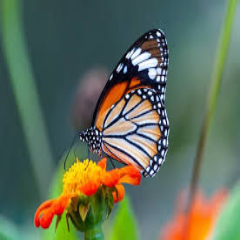

In [6]:
img = cv2.imread("/content/butterfly.jpg")
resize= cv2.resize(img, (240,240))
print(resize.shape)
cv2_imshow(resize)

**Experiment 1**

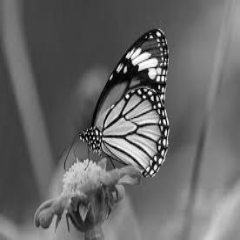

In [7]:
from cv2.gapi import BGR2Gray
gray = cv2.cvtColor(resize, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

**Exmperiment 2: Image Fitering**

(240, 240)
9 239


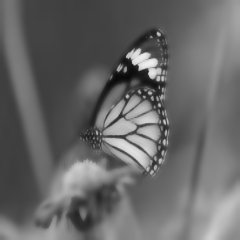

In [8]:
bilateral= cv2.bilateralFilter(gray, d=9, sigmaColor=75,sigmaSpace=75)
print(bilateral.shape)
print(bilateral.min(), bilateral.max())
cv2_imshow(bilateral)

(240, 240)


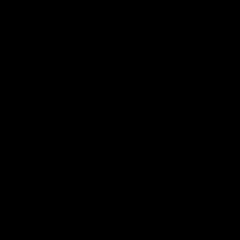

0.03529412 0.9372549


In [9]:
norm_img = bilateral.astype(np.float32)/255.0
print(norm_img.shape)
cv2_imshow(norm_img)
print(norm_img.min(),norm_img.max())

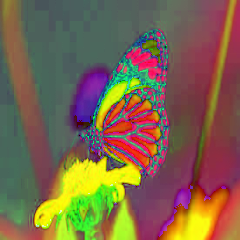

In [10]:
hsv= cv2.cvtColor(resize, cv2.COLOR_BGR2HSV)
cv2_imshow(hsv)

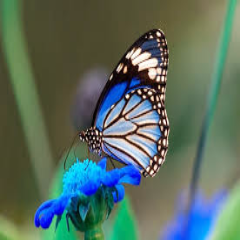

In [11]:
RGB= cv2.cvtColor(resize, cv2.COLOR_BGR2RGB)
cv2_imshow(RGB)

**Guassian Blur**

(240, 240)
5 247


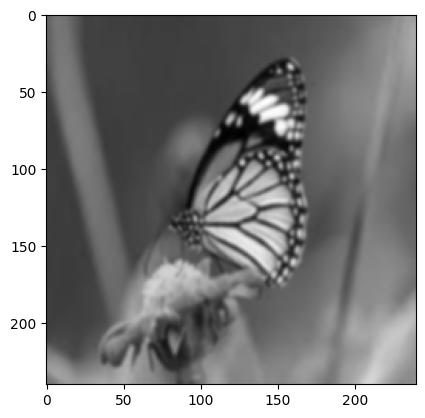

In [12]:
guassian=cv2.GaussianBlur(gray, (5,5), sigmaX=0)
plt.imshow(guassian, cmap='gray')
print(guassian.shape)
print(guassian.min(), guassian.max())

**Median Blur**

(240, 240)
6 247


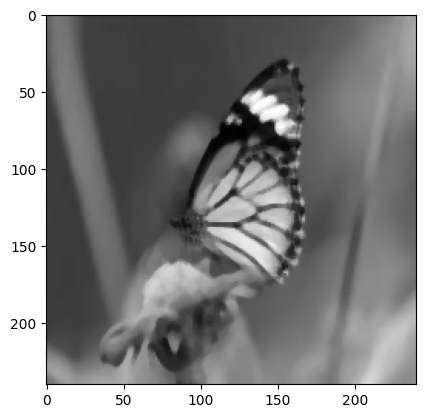

In [13]:
median= cv2.medianBlur(gray,5)
print(median.shape)
print(median.min(), median.max())
plt.imshow(median, cmap='gray')

**Augmentation**

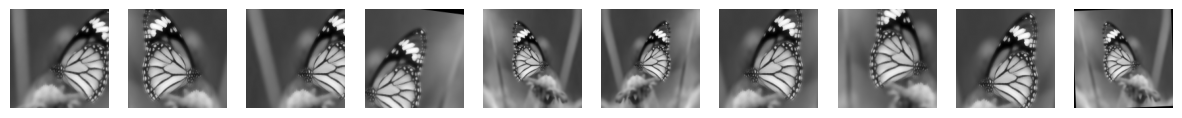

In [14]:
import albumentations as A
transform= A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=15,p=0.3),
    A.RandomCrop(height=150, width= 150, p=0.5)
])
fig, axes = plt.subplots(1, 10, figsize=(15, 10))

for i in range(10):
    augmented=transform(image=norm_img)
    aug_img=augmented["image"]
    axes[i].imshow(aug_img, cmap= 'gray')
    axes[i].axis("off")


**Experiment 3: Edge Detection**

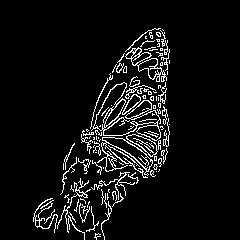

In [15]:
edges= cv2.Canny(gray, threshold1=100, threshold2=200)
cv2_imshow(edges)

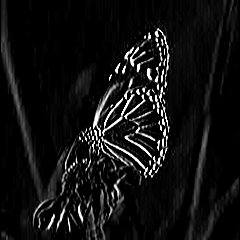

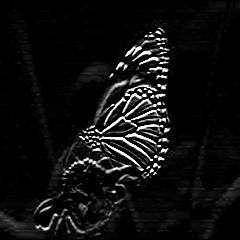

In [16]:
Sobelx = cv2.Sobel(gray, cv2.CV_64F,1,0, ksize=3)
Sobely = cv2.Sobel(gray, cv2.CV_64F,0,1,ksize=3)
cv2_imshow(Sobelx)
cv2_imshow(Sobely)

**Adaptive Thresholding**

In [29]:
binary = cv2.adaptiveThreshold(
    median,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

In [30]:
kernel = np.ones((5,5), np.uint8)

binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

**Experiment 4: Contour Dtection**

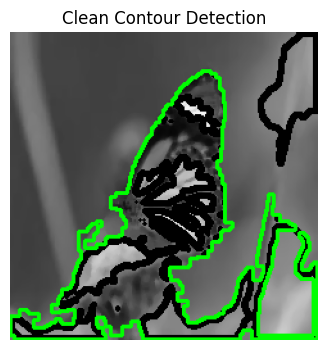

In [32]:
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

largest_contour = max(contours, key=cv2.contourArea)
result = cv2.cvtColor(median, cv2.COLOR_GRAY2BGR)

cv2.drawContours(
    result,
    [largest_contour],
    -1,
    (0, 255, 0),
    2
)

plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Clean Contour Detection")
plt.axis('off')
plt.show()

**Experiment 5: Shape Detection**

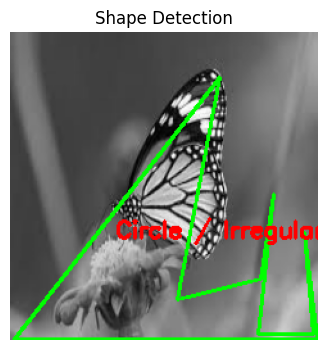

In [33]:
# Perimeter of contour
peri = cv2.arcLength(largest_contour, True)

# Approximate contour
approx = cv2.approxPolyDP(
    largest_contour,
    0.02 * peri,   # epsilon (accuracy)
    True
)
vertices = len(approx)

if vertices == 3:
    shape = "Triangle"
elif vertices == 4:
    shape = "Quadrilateral"
elif vertices == 5:
    shape = "Pentagon"
elif vertices > 5:
    shape = "Circle / Irregular"
else:
    shape = "Unknown"

result = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

cv2.drawContours(result, [approx], -1, (0, 255, 0), 2)

# Compute centroid for text placement
M = cv2.moments(largest_contour)
if M["m00"] != 0:
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
else:
    cx, cy = 50, 50

cv2.putText(
    result,
    shape,
    (cx - 40, cy),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (0, 0, 255),
    2
)

plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Shape Detection")
plt.axis('off')
plt.show()